## init

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA").config("spark.sql.shuffle.partitions", "4000").config("spark.executor.memoryOverhead", "4g").getOrCreate()

bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)
bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by bash)


26/03/09 05:46:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/09 05:46:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/09 05:46:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/03/09 05:46:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of 

In [17]:
date = "2026-02-25"
path_to_data = f"gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day={date}"
df = spark.read.parquet(path_to_data)

In [2]:
from datetime import datetime, timedelta

date = "2026-03-05"
base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"
date_format = "%Y-%m-%d"

base_date = datetime.strptime(date, date_format)

paths = [
    f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(30)
]

df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if df is None:
            df = temp_df
        else:
            df = df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")

26/03/09 05:47:11 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


## Graph testing 1

In [23]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprint
streamable_df = (
    df.select(
        "userId",
        "content_id", 
        "total_play_time_sec",
        "content_content_type"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

In [30]:
combined_playtime = (
    streamable_df.select("userid", "content_id", "total_play_time_sec", "content_content_type")  # Repartition for better parallelization
    .groupBy("userid", "content_id", "content_content_type")
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined"),
        F.count("*").alias("num_sessions")
    )
)

### testing dists

In [ ]:
from pyspark.sql import functions as F

watch_dist = (
    combined_playtime.groupBy("content_content_type")
      .agg(F.sum("total_playtime_combined").alias("total_watch_time"))
)

watch_dist.show()

+--------------------+--------------------+
|content_content_type|    total_watch_time|
+--------------------+--------------------+
|               MOVIE| 6.841097019119993E8|
|             EPISODE|1.0156314415769988E9|
|              SEASON|             22123.0|
|               VIDEO|5.0585796662999995E7|
|              TVSHOW|          141001.034|
+--------------------+--------------------+



26/03/06 10:33:28 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 4 for reason Executor for container container_1764236692086_4612_01_000007 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


In [ ]:
user_pref = (
    combined_playtime.groupBy("userid", "content_content_type")
      .agg(F.sum("total_playtime_combined").alias("watch_time"))
).orderBy("userid").show()

26/03/06 10:36:03 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 1 for reason Executor for container container_1764236692086_4612_01_000003 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


+------------------+--------------------+------------------+
|            userid|content_content_type|        watch_time|
+------------------+--------------------+------------------+
|                  |               MOVIE|           30682.0|
|                  |             EPISODE|            3547.0|
|--03-VasNdpfk0Fa20|               MOVIE|3494.3810000000003|
|--17p0Yk5D3V9JME40|               MOVIE|            3999.0|
|--1o8po0M4ISH2BO50|             EPISODE|          1324.704|
|--1x4ql9mzvdg-3Ir0|             EPISODE|          5227.995|
|--1x4ql9mzvdg-3Ir0|               MOVIE|          3110.589|
|--2FN_l_OOXV9M1hg0|             EPISODE|          1214.318|
|--2rOSAcWozwI0Qer0|               MOVIE|          1645.955|
|--3NKB8gzI3SlEDyn0|               MOVIE|          2778.552|
|--3hWdDYnhvQQWQON0|               MOVIE|            5572.0|
|--41ldMrROFBLl64r0|               MOVIE|           210.964|
|--41ldMrROFBLl64r0|             EPISODE|           262.547|
|--4Rlo_Vwz0YMy2Yw0|    

26/03/06 10:37:12 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 6 for reason Executor for container container_1764236692086_4612_01_000009 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


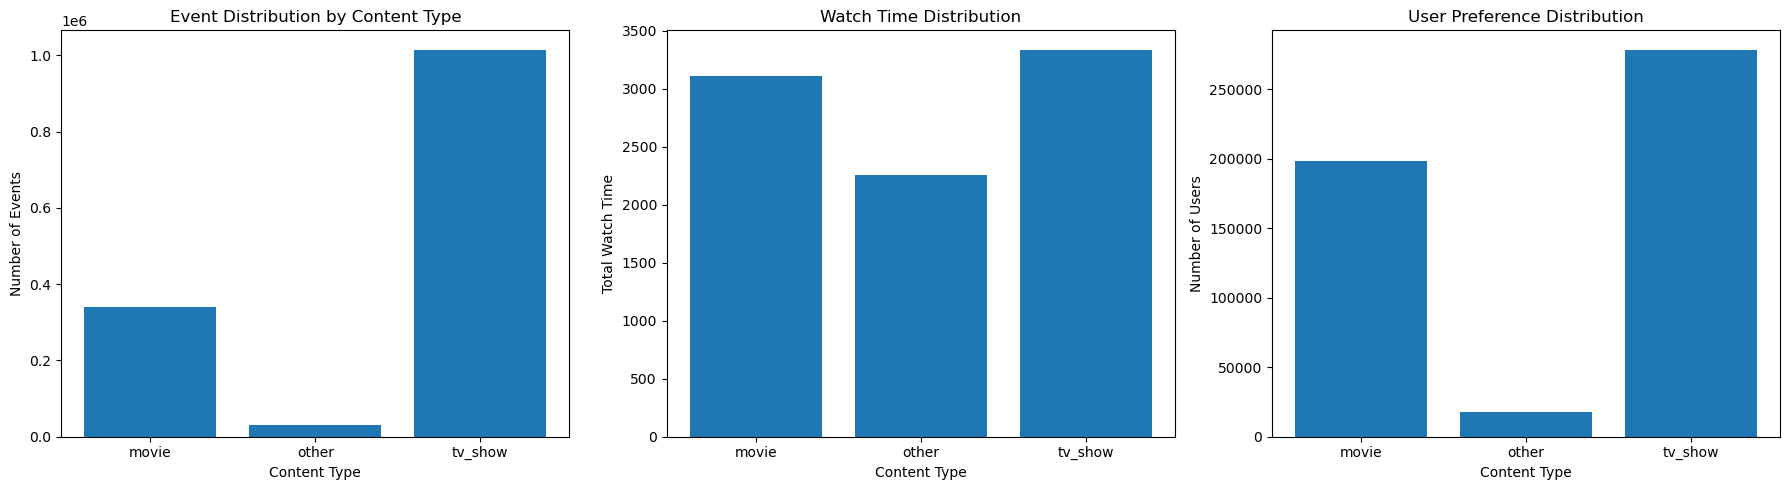

In [41]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Normalize content types
# -----------------------------

df_clean = combined_playtime.withColumn(
    "content_type_grouped",
    F.when(F.lower(F.col("content_content_type")).isin("episode", "tvshow", "tv show", "tv_shows"), "tv_show")
     .when(F.lower(F.col("content_content_type")).isin("movie", "film"), "movie")
     .otherwise("other")
)

# -----------------------------
# 2. EVENT DISTRIBUTION
# -----------------------------

event_dist = (
    df_clean
    .groupBy("content_type_grouped")
    .count()
)

event_pd = event_dist.toPandas()

# -----------------------------
# 3. WATCH TIME DISTRIBUTION
# -----------------------------

watch_dist = (
    df_clean
    .groupBy("content_type_grouped", "userid")
    .agg(F.sum("total_playtime_combined").alias("user_watch_time"))
    .groupBy("content_type_grouped")
    .agg(F.avg("user_watch_time").alias("avg_watch_time"))
)

watch_pd = watch_dist.toPandas()

# -----------------------------
# 4. USER PREFERENCE DISTRIBUTION
# -----------------------------

user_watch = (
    df_clean
    .groupBy("userid", "content_type_grouped")
    .agg(F.sum("total_playtime_combined").alias("watch_time"))
)

from pyspark.sql.window import Window

window = Window.partitionBy("userid").orderBy(F.col("watch_time").desc())

user_pref = (
    user_watch
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") == 1)
    .groupBy("content_type_grouped")
    .count()
)

user_pref_pd = user_pref.toPandas()

# -----------------------------
# 5. VISUALIZATIONS
# -----------------------------

fig, axes = plt.subplots(1,3, figsize=(18,5))

# Event distribution
axes[0].bar(event_pd["content_type_grouped"], event_pd["count"])
axes[0].set_title("Event Distribution by Content Type")
axes[0].set_xlabel("Content Type")
axes[0].set_ylabel("Number of Events")

# Watch time distribution
axes[1].bar(watch_pd["content_type_grouped"], watch_pd["avg_watch_time"])
axes[1].set_title("Watch Time Distribution")
axes[1].set_xlabel("Content Type")
axes[1].set_ylabel("Total Watch Time")

# User preference distribution
axes[2].bar(user_pref_pd["content_type_grouped"], user_pref_pd["count"])
axes[2].set_title("User Preference Distribution")
axes[2].set_xlabel("Content Type")
axes[2].set_ylabel("Number of Users")

plt.tight_layout()
plt.show()

## count of content watched per user

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Recommendation_Engine_tinker") \
    .getOrCreate()

In [ ]:
from datetime import datetime, timedelta

date = "2026-03-05"
base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"
date_format = "%Y-%m-%d"

base_date = datetime.strptime(date, date_format)

paths = [
    f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(30)
]

df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if df is None:
            df = temp_df
        else:
            df = df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")

1. Select importatnt columns
2. count the number of instances
3. group by count of instances
4. get count and distribution of this group

In [9]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprint
streamable_df = (
    df.select(
        "userId",
        "content_id", 
        "total_play_time_sec",
        "content_content_type"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

combined_playtime = (
    streamable_df.select("userid", "content_id", "total_play_time_sec", "content_content_type")  # Repartition for better parallelization
    .groupBy("userid", "content_id", "content_content_type")
    .agg(
        F.sum("total_play_time_sec").alias("playtime_sec"),
        F.count("*").alias("num_sessions")
    )
)


In [ ]:
user_distinct_content_count_df.show(10, truncate=False)

+------------------+----------------------+
|userid            |distinct_content_count|
+------------------+----------------------+
|Vu8tZ0dpHxYpQVUHm0|122                   |
|QgCU_vKdz81wagBLt0|52                    |
|_-pZkThbdN4k3738l0|17                    |
|O-xRAhKf21bGYSpta0|2                     |
|Hud8e_LaCWchNEBLS0|2                     |
|bCLzRJ8579MfsgdLj0|15                    |
|Z--qkq4v8NvLBKwJA0|17                    |
|262r-3LS0I_i8YWg-0|7                     |
|pktZjfUgHDAGA-wAp0|9                     |
|WSnug4TOCZ8fHC8GZ0|30                    |
+------------------+----------------------+
only showing top 10 rows



26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 15 for reason Executor for container container_1764236692086_4733_01_000015 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 4 for reason Executor for container container_1764236692086_4733_01_000004 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/09 06:03:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 13 for reason Executor for container container_1764236692086_4733_01_000013 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


In [13]:
from pyspark.sql import functions as F

user_distinct_content_count_df = (
    combined_playtime
    .filter(F.col("playtime_sec") > 300)
    .groupBy("userid")
    .agg(F.count_distinct("content_id").alias("distinct_content_count"))
).cache()

/tmp/ipykernel_3520773/3931902583.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


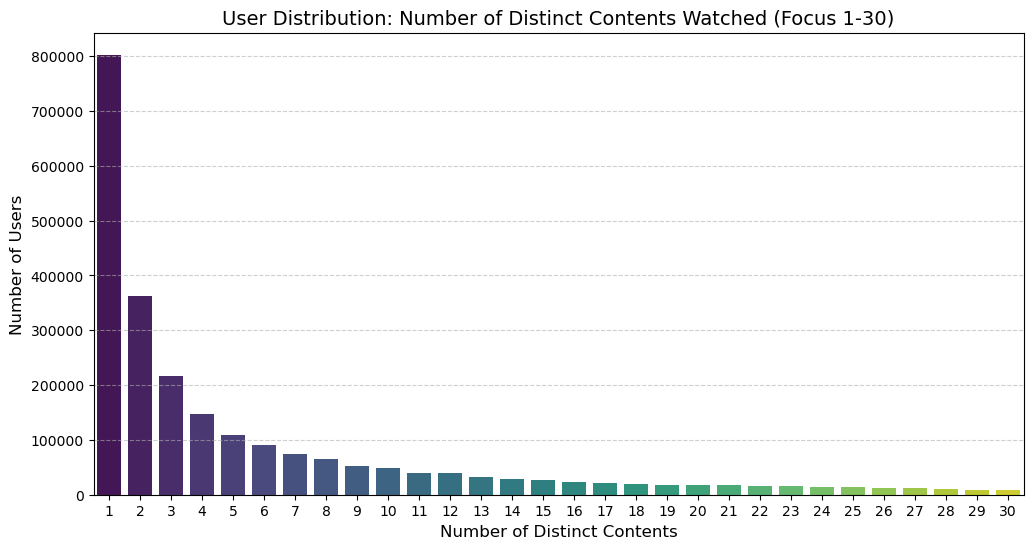

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate: Count how many users fall into each "content count" bucket
# We sort by the count of contents to make the X-axis linear (1, 2, 3...)
dist_data = (
    user_distinct_content_count_df
    .groupBy("distinct_content_count")
    .count()
    .orderBy("distinct_content_count")
)

# 2. Focus on "Lower Numbers": Filter for users with 1 to 30 contents 
# This prevents high-count outliers from squishing the graph
plot_df = dist_data.filter("distinct_content_count <= 30").toPandas()
# plot_df = dist_data.toPandas()

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x="distinct_content_count", 
    y="count", 
    data=plot_df, 
    palette="viridis"
)

# Adding labels and styling
plt.title("User Distribution: Number of Distinct Contents Watched (Focus 1-30)", fontsize=14)
plt.xlabel("Number of Distinct Contents", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [20]:
print("Users watching >= 1 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 1").count())
print("Users watching >= 2 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 2").count())
print("Users watching >= 3 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 3").count())
print("Users watching >= 5 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 5").count())
print("Users watching >= 10 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 10").count())
print("Users watching >= 20 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 20").count())
print("Users watching >= 50 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 50").count())
print("Users watching >= 100 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 100").count())

Users watching >= 1 content:	 2520461
Users watching >= 2 content:	 1717764
Users watching >= 3 content:	 1355891
Users watching >= 5 content:	 992378
Users watching >= 10 content:	 599529
Users watching >= 20 content:	 299764
Users watching >= 50 content:	 62172
Users watching >= 100 content:	 16649


In [23]:
# Define the percentiles you want (expressed as decimals 0.0 to 1.0)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Calculate the values
# 0.01 is the relative error: lower is more accurate but slower
quantile_values = user_distinct_content_count_df.stat.approxQuantile(
    "distinct_content_count", 
    percentiles, 
    0.01
)

# Pair them up and print the results
print("--- User Content Consumption Percentiles ---")
for p, v in zip(percentiles, quantile_values):
    print(f"{int(p*100)}th Percentile: {int(v)} contents")

--- User Content Consumption Percentiles ---
25th Percentile: 1 contents
50th Percentile: 3 contents
75th Percentile: 9 contents
90th Percentile: 21 contents
95th Percentile: 31 contents
99th Percentile: 3048 contents
